# Zero-Shot Image Tagging with CLIP for a Second-Hand Marketplace

## The situation

You run catalog quality at **Zweitmarkt**, a Swiss second-hand marketplace. Sellers upload
around 40,000 listings a week: they snap a photo, type a description and pick a category from a
long menu, or they don't. About a third of all listings end up in the wrong category or in none,
and a listing in the wrong category is a listing nobody finds.

Two more facts make it harder:

- **The catalog keeps changing.** Last spring the category team opened an **antiques section**
  and split Windsor chairs from chairs and ewers (decorative jugs) from cups, because the antique
  versions sell for ten times the price.
- **Some listings must never go online.** Zweitmarkt bans **money**: banknotes are a
  classic route for counterfeit notes and payment fraud, and people list "rare" bills anyway.

A classic image classifier needs thousands of labeled photos per category and a new training run
every time the catalog changes. Your data science colleague suggests **CLIP**, a pre-trained model
you hand your categories to *as plain text*. Before you sign off, you want answers to four
questions:

1. Can a model tag photos with categories it was never trained on?
2. How reliable are its tags, and where does it go wrong?
3. Does it matter how we word the categories?
4. How do we stop it from confidently tagging listings that fit no category?

## What's ahead

0. 🎮 **Match.** A two-round matching game. Play first, the name comes after.
1. **Encode.** Photos and category descriptions become vectors.
2. **Compare.** How close is a listing to a category?
3. **Tag.** The closest category wins, and what CLIP's percentages really mean.
4. **Word it.** Category descriptions are configuration, and need testing.
5. **Review.** A rule for when a moderator should look instead.

⭐ **Bonus.** A new category by lunchtime.

**How the tasks work.** Cells that start with `# 🎯 YOUR TURN` have gaps: replace every `...`
and run the cell. Everything else is given, just run it. The whole tagging engine is five lines,
and you write the key part of each:

```python
listing_vecs  = embed_images(photos)                                  # Part 1: photos to vectors
category_vecs = embed_texts(descriptions)                             # Part 1: your words to vectors
closeness     = normalize(listing_vecs) @ normalize(category_vecs).T  # Part 2
tags          = closeness.argmax(dim=1)                               # Part 3
needs_review  = closeness.max(dim=1).values < REVIEW_THRESHOLD        # Part 5
```

In [1]:
#@title 🗺️ Roadmap (double-click to view the code) { display-mode: "form" }
from IPython.display import HTML, display

_STEPS = [
    ("0", "Match", "play the game CLIP was trained on", "#667eea", "#764ba2"),
    ("1", "Encode", "photos and words become vectors", "#764ba2", "#e0796d"),
    ("2", "Compare", "closeness in one shared space", "#e0796d", "#e0a23c"),
    ("3", "Tag", "the closest category wins", "#e0a23c", "#39b36a"),
    ("4", "Word it", "descriptions are configuration", "#39b36a", "#667eea"),
    ("5", "Review", "when not to trust the tag", "#667eea", "#e0796d"),
]


def _roadmap_html(steps):
    cards = []
    for num, title, sub, c1, c2 in steps:
        cards.append(f"""
        <div style="flex: 1 1 140px; min-width: 130px; background: #fff;
                    border: 1px solid #e6e8ee; border-radius: 14px;
                    padding: 14px 10px; text-align: center;">
          <div style="width: 42px; height: 42px; margin: 0 auto 10px;
                      border-radius: 50%; display: flex; align-items: center;
                      justify-content: center; color: #fff; font-weight: 700;
                      font-size: 1.05rem;
                      background: linear-gradient(135deg, {c1}, {c2});">{num}</div>
          <div style="font-weight: 650; color: #23262f; font-size: .98rem;">{title}</div>
          <div style="color: #6b7280; font-size: .82rem; margin-top: 4px;">{sub}</div>
        </div>""")
    return f"""
    <div style="font-family: system-ui, Segoe UI, Roboto, sans-serif;
                border-radius: 18px; border: 1px solid #ecebff; padding: 18px;
                background: linear-gradient(135deg, #f6f8ff, #fbf5ff);">
      <div style="font-weight: 800; font-size: 1.1rem; color: #23262f;">
        🗺️ Roadmap: tagging Zweitmarkt listings with CLIP</div>
      <div style="color: #6b7280; font-size: .9rem; margin-top: 4px;">
        From a matching game to a tagging rule you would sign off on.</div>
      <div style="display: flex; flex-wrap: wrap; gap: 10px; margin-top: 14px;">
        {"".join(cards)}</div>
    </div>"""


display(HTML(_roadmap_html(_STEPS)))

In [2]:
#@title ⚙️ Setup: run this cell first (double-click to view the code) { display-mode: "form" }
import warnings
warnings.filterwarnings("ignore")

# The one place to change the model.
MODEL_ID = "openai/clip-vit-base-patch32"
RANDOM_STATE = 42

# clip_support.py, listings.csv and widget_data.json, gzipped and base64 encoded, so
# this notebook needs no clone. EDIT THE FILES IN THE COURSE REPOSITORY, NEVER THIS
# BLOB: build_notebooks.py rebuilds it.
_MODULES = (
    "..."
    "890W5Zdf/uOX/wMeQyj8fV0CAA=="
)

import base64, gzip, json, os, sys, importlib, subprocess
try:
    import transformers, datasets  # preinstalled on Colab
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers", "datasets"],
                   check=True)

# The files go into their own folder, never the working directory.
_SRC_DIR = "cx_clip_src"
os.makedirs(_SRC_DIR, exist_ok=True)
for _name, _src in json.loads(gzip.decompress(base64.b64decode("".join(_MODULES)))).items():
    with open(os.path.join(_SRC_DIR, _name), "w", encoding="utf-8") as fh:
        fh.write(_src)
if _SRC_DIR not in sys.path:
    sys.path.insert(0, _SRC_DIR)
sys.modules.pop("clip_support", None)   # rerunning setup picks up a rebuilt module
importlib.invalidate_caches()

import torch
import clip_support
clip_support.MODEL_ID = MODEL_ID
from clip_support import (
    CLIP_SCALE, PURPLE, PURPLE2, GREEN, RED, AMBER,
    CATEGORY_NAMES, CATEGORY_PHRASES, NEW_CATEGORY_NAMES,
    REVIEW_COST, WRONG_TAG_COST, BANNED_COST,
    load_listings, load_clip, embed_images, embed_texts, check_filled,
    show_matching_game, show_two_encoders, show_listings, plot_closeness,
    show_softmax_explorer, show_tag_gallery, compare_wordings, show_out_of_catalog,
    show_threshold_explorer, review_report, show_new_categories,
)
torch.manual_seed(RANDOM_STATE)
print("Setup complete.")

Setup complete.


## Part 0 — 🎮 Warm-up: can you match the listings?

No code yet. Four listings arrived without a category, each with its seller's description. Match
every photo to its description, check your answer, then see how the model you are evaluating did
on the same puzzle. Two short rounds.


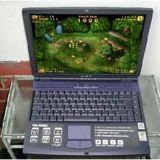
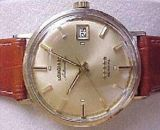
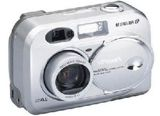
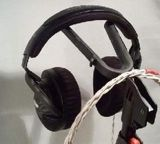
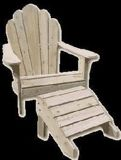
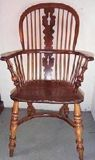
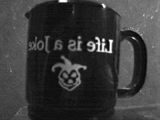
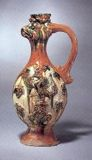

In [3]:
#@title 🎮 The matching game (double-click to view the code) { display-mode: "form" }
show_matching_game()

The game's last button named the mechanism: CLIP was trained on hundreds of millions of photos and
their captions to play exactly this matching game. Here is the same idea as a picture, with the
real numbers for one of this week's listings. Everything that follows builds this machine piece
by piece.


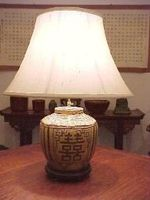

In [4]:
#@title 🧩 Visualization: two encoders, one shared space (double-click to view the code) { display-mode: "form" }
show_two_encoders()

## Part 1 — Encode: what does CLIP make of a listing and a category?

Time for this week's inbox. It holds 120 listings. For Parts 1 to 4 we use the
96 that belong to one of Zweitmarkt's twelve categories; Part 5 brings in the rest.
The next two cells load the listings and the model (about 600 MB, downloaded once per session).

Listings downloaded from the course repository.
96 catalog listings loaded (plus 24 more in the full inbox, for Part 5).


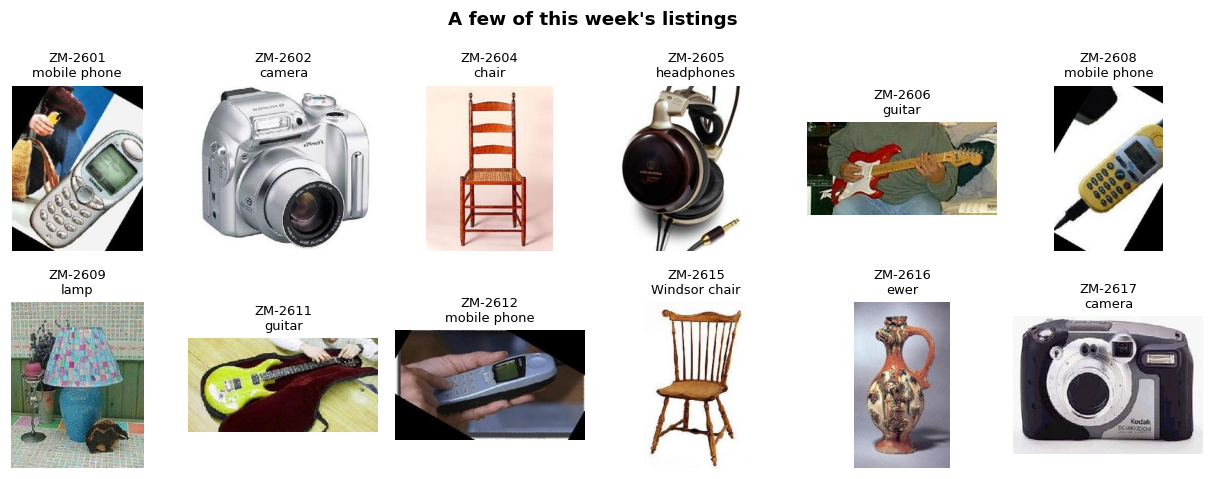

In [5]:
#@title 📦 Load this week's listings (double-click to view the code) { display-mode: "form" }
listings, inbox = load_listings()
show_listings(listings, n=12)

In [8]:
#@title 🧠 Load the pre-trained CLIP model (double-click to view the code) { display-mode: "form" }
model, processor = load_clip()
print(f"CLIP loaded: {MODEL_ID}")

CLIP loaded: openai/clip-vit-base-patch32


## 🎯 Task 1. Describe the catalog in words

**Task.** Write one description per category, in the same order as `CATEGORY_NAMES`.

CLIP's categories are whatever text you give it. Zweitmarkt's twelve categories are in
`CATEGORY_NAMES`:

> laptop, mobile phone, camera, headphones, watch, chair, Windsor chair, lamp, cup, ewer, guitar, mandolin

For each one you write a **description**, which the text encoder turns into a vector. The standard
starting point, from the CLIP paper itself, is a plain caption such as `"a photo of a laptop"`.
CLIP learned from photo captions, so a description that reads like a caption sits closest to what
it saw during training.

### Your turn

In [17]:
# 🎯 YOUR TURN — Task 1: describe Zweitmarkt's twelve categories in words.
#
# 💭 Think first: CLIP has never seen Zweitmarkt's catalog. What do your twelve short
#    sentences have to carry for it to tell a Windsor chair from a chair?
#
# 🎯 Implement: a list of twelve strings in the order of CATEGORY_NAMES, each a plain
#    caption like "a photo of a laptop" (mind "an ewer", and "headphones" without "a").
#    Store it in `descriptions`.
descriptions = ["a photo of a mobile phone","a photo of a camera", "a photo of a chair", "a photo of headphones", "a photo of a guitar", "a photo of a mobile phone", "a photo of a lamp", "a photo of a guitar", "a photo of a mobile phone", "a photo of a windsor chair", "a photo of a vase", "a photo of a camera"]
check_filled(descriptions, "descriptions")
print(len(descriptions), "descriptions, one per category")

12 descriptions, one per category


In [18]:
listing_vecs = embed_images(listings["photo"])   # image encoder: one vector per listing photo
category_vecs = embed_texts(descriptions)         # text encoder: one vector per description

print("listing_vecs: ", tuple(listing_vecs.shape), " one row of 512 numbers per listing")
print("category_vecs:", tuple(category_vecs.shape), "  one row of 512 numbers per category")
print("\nThe first listing's first 8 numbers:", listing_vecs[0, :8].numpy().round(2))

listing_vecs:  (96, 512)  one row of 512 numbers per listing
category_vecs: (12, 512)   one row of 512 numbers per category

The first listing's first 8 numbers: [ 0.22  0.67 -0.09 -0.19  0.51 -0.36 -0.04  0.79]


**Reading the result.** Every photo and every description is now a list of 512 numbers, a
*vector*. The single numbers mean nothing to a human; what matters is how two vectors compare,
which is Part 2. Notice what this cost you: twelve lines of text. The expensive part, a model
that understands photos, was paid for once by the model's training, and any company can reuse it.

## Part 2 — Compare: how close is a listing to a category?

Part 1 turned photos and descriptions into vectors. Now we compare them.

## 🎯 Task 2. Closeness of every listing to every category

**Task.** Complete `normalize`, then compute the closeness table.

Picture each vector as an arrow in a space with 512 directions. CLIP was trained so that the arrow
of a photo and the arrow of its caption **point the same way**. How long an arrow is carries no
meaning (a bright photo and a dark photo of the same laptop give arrows of different lengths), so
we compare **directions only**. The standard measure is the *cosine similarity*; we call it
**closeness**:

$$\text{closeness}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{\lVert \mathbf{u} \rVert \, \lVert \mathbf{v} \rVert}$$

Here $\mathbf{u}$ is a listing's photo vector and $\mathbf{v}$ a category's description vector.
$\mathbf{u} \cdot \mathbf{v}$ multiplies the two vectors number by number and adds up all 512
products, and $\lVert \mathbf{u} \rVert$ is the arrow's length. Closeness is 1 when two arrows
point exactly the same way and around 0 when they are unrelated.

In code it takes two steps. First **normalize**: divide every vector by its length, so all arrows
have length 1. Then the closeness of every listing to every category is one matrix multiplication,
`A @ B.T`: each row of `A` (a listing) times each row of `B` (a category).

### Your turn

closeness: (96, 12)  one row per listing, one column per category


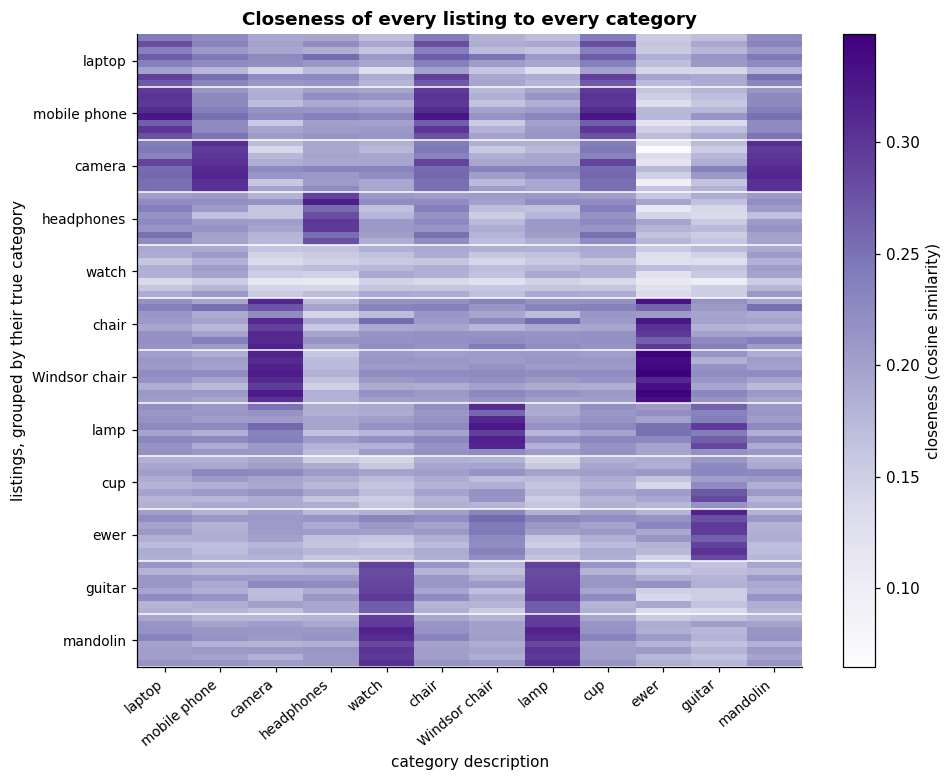

Closeness ranges from 0.06 to 0.35. A listing's best category scores 0.28 on average.


In [19]:
# 🎯 YOUR TURN — Task 2: closeness of every listing to every category.
#
# 💭 Think first: the game's grid showed values between about 0.15 and 0.35, never near 1.
#    A photo and a sentence are very different things. Why can 0.30 still be a strong match?
#
# 🎯 Implement: (a) `normalize` divides every row of `vectors` by its length, which is
#    `vectors.norm(dim=-1, keepdim=True)`; (b) `closeness` is the normalized listing vectors
#    times the transposed normalized category vectors: `A @ B.T`.
def normalize(vectors):
    return vectors/vectors.norm(dim=-1, keepdim=True)


closeness = normalize(listing_vecs) @ normalize(category_vecs).T

check_filled(closeness, "closeness")
print("closeness:", tuple(closeness.shape), " one row per listing, one column per category")
plot_closeness(closeness, listings)

**Reading the heatmap.** The dark blocks on the diagonal are the whole idea working: every group
of listings is closest to its own category, and CLIP has never seen Zweitmarkt's catalog. Look at
the scale, though. A strong match scores about 0.30, an unrelated pair
about 0.20. Tags are decided by gaps of a few hundredths, which is why the next part converts them
into something easier to act on. And look at the **chair** rows: dark in two columns, *chair* and
*Windsor chair*. Keep that in mind.

## Part 3 — Tag: the closest category wins. How sure is CLIP?

## 🎯 Task 3. Tag every listing

**Task.** Turn the closeness table into percentages, a tag per listing, and CLIP's confidence in
that tag.

Tagging a listing means picking the column with the highest closeness in its row. But the first
thing a manager asks is *how sure is it?* CLIP answers with percentages, computed by a **softmax**:
multiply every closeness by a scale CLIP learned during training (100 for this model), and turn
the results into shares that add up to 100%:

$$p_k = \frac{e^{100 \cdot c_k}}{\sum_{j} e^{100 \cdot c_j}}$$

Here $c_k$ is the listing's closeness to category $k$, $p_k$ is the percentage CLIP reports for
it, and the sum runs over **the categories you offered**. The scale of 100 turns small gaps into
large ones: a closeness gap of 0.03 becomes a weight ratio of $e^{3} \approx 20$.

That last part, *the categories you offered*, is the one to remember. Try it before you code it.


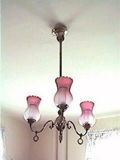
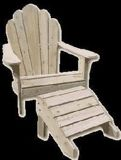
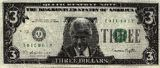

In [20]:
#@title 🎛️ Visualization: percentages are shares of the menu (double-click to view the code) { display-mode: "form" }
show_softmax_explorer()

The closeness of a photo to a category never changes; it only depends on the two vectors. The
percentage is a *share of the menu*: add or remove a category and every percentage moves, even
though the photo is the same. Keep that in mind while you write the code.

### Your turn

In [ ]:
# 🎯 YOUR TURN — Task 3: from closeness to a tag and a confidence.
#
# 💭 Think first: after the widget, what would you answer a colleague who says "CLIP is
#    95% sure, so we can publish without checking"?
#
# 🎯 Implement: (a) `probs`: CLIP_SCALE times closeness, then `.softmax(dim=1)`;
#    (b) `tags`: the column with the highest percentage in each row, `.argmax(dim=1)`;
#    (c) `confidence`: the highest percentage in each row, `.max(dim=1).values`.
probs = ...
tags = ...
confidence = ...

show_tag_gallery(listings, tags, confidence)

**Reading the result.** 89 of 96 listings tagged correctly
(92.7%), with no training and twelve lines of text. Nine of the twelve categories
are flawless. Every mistake falls inside a look-alike pair: chair → Windsor chair (3×), mandolin → guitar (2×), cup → ewer (2×). The garden chair from the
game (ZM-2656) is one of them: the seller's detailed description saved it in the
game, the short category name does not. The mistakes are no coin flips either: CLIP's median
confidence on a wrong tag is 82%.

This is not a silly error. A Windsor chair *is* a chair, and the catalog asks CLIP to separate a
category from its own sub-type. On a larger benchmark of 814 labeled photos, plain
chairs land in *Windsor chair* 48% of the time. For the business
that means the antiques section, the part of the catalog with the highest prices, is exactly
where automatic tags are least reliable.

## Part 4 — Word it: do the category descriptions matter?

## 🎯 Task 4. Sharpen the descriptions

**Task.** Write your own twelve descriptions, aimed at the look-alike pairs.

Your twelve descriptions are **configuration**: nobody writes code for them, the category team
owns them, and they change what the product does. So test whether better wording fixes the
look-alikes.

How do you judge a change? This week's 96 listings are few: one listing is a full
percentage point. The category team therefore keeps a **benchmark**: the other 814
labeled photos of the same twelve categories, already run through the image encoder. Every
wording below is scored on both.

### Your turn

In [ ]:
# 🎯 YOUR TURN — Task 4: your own wording for the twelve categories.
#
# 💭 Think first: a buyer tells a Windsor chair from a garden chair in a second. What
#    would you write so that a model trained on photo captions can too?
#
# 🎯 Implement: twelve descriptions in the order of CATEGORY_NAMES. Keep what worked and
#    rewrite the look-alikes (chair / Windsor chair, cup / ewer, guitar / mandolin), for
#    example by naming what you see. Store them in `my_descriptions`.
my_descriptions = ...

check_filled(my_descriptions, "my_descriptions")
my_vecs = embed_texts(my_descriptions)
compare_wordings(listing_vecs, listings, {
    "Task 1 wording": category_vecs,
    "your wording": my_vecs,
})

## 🎯 Task 5. One averaged vector per category (prompt ensembling)

**Task.** For every category, fill in the four templates, embed them, and average.

Any single sentence has quirks: CLIP may associate "a photo of" with a certain kind of picture.
**Prompt ensembling**, used in the CLIP paper itself, writes each category in several phrasings
and averages their vectors, so the quirks cancel out and the category's meaning stays:

$$\mathbf{v}_k = \text{normalize}\Big(\frac{1}{T} \sum_{t=1}^{T} \text{normalize}\big(\text{encode}(\text{phrasing}_t(k))\big)\Big)$$

Here $\mathbf{v}_k$ is the new vector for category $k$, $T$ is the number of phrasings,
$\text{phrasing}_t(k)$ is the $t$-th template filled with the category (for example
"a close-up photo of a laptop."), and $\text{encode}$ is the text encoder.

### Your turn

In [ ]:
TEMPLATES = ["a photo of {}.", "a close-up photo of {}.", "a blurry photo of {}.", "a drawing of {}."]

# 🎯 YOUR TURN — Task 5: one averaged vector per category.
#
# 🎯 Implement: for each category phrase ("a laptop", "a mobile phone", ...), (a) `texts`:
#    every template filled with it, `template.format(phrase)`; (b) `vecs`: those texts
#    embedded with `embed_texts` and normalized; (c) append their average, `.mean(dim=0)`.
#    The last line then normalizes the averages.
ensemble_vecs = []
for phrase in CATEGORY_PHRASES:
    texts = ...
    vecs = ...
    ensemble_vecs.append(...)

check_filled(ensemble_vecs, "ensemble_vecs")
ensemble_vecs = normalize(torch.stack(ensemble_vecs))

compare_wordings(listing_vecs, listings, {
    "Task 1 wording": category_vecs,
    "your wording": my_vecs,
    "4 phrasings, averaged": ensemble_vecs,
})

**Reading the result.** On this week's 96 listings, averaging four phrasings changes
nothing visible (92.7% before and 92.7% after). On the benchmark it
gains about a point (93.5% to 94.5%), and plain chairs go
from 52% to 61% correct. Both
statements are true at once: the improvement is real, and far too small to see on one week of
listings. Sharper wording behaves the same way. One version we tried, which describes the
cushions of a chair and the spindles of a Windsor chair, lifts chairs to
63% on the benchmark while this week looks one listing *worse*.
A description like "an office chair", on the other hand, makes chairs much worse. Wording can hurt
as easily as it helps.

Two lessons for the business:

- **Judge configuration changes on a benchmark, never on last week's inbox.** Small samples point
  the wrong way often enough to fool you.
- **No wording separates a category from its own sub-type reliably.** Chairs stay close to a coin
  flip. That is a catalog decision, not a prompt problem: merge the two and let an antiques
  specialist sub-tag, or send every chair listing to review.

## Part 5 — Review: which listings should a human see?

So far every listing belonged to the catalog. The full inbox also holds 12 listings of
**banknotes** (banned: real or counterfeit, money is not for sale) and 12 **chandeliers and binoculars**, which Zweitmarkt has no
category for yet. Here is what CLIP does with them, using your Task 1 descriptions:

In [ ]:
inbox_vecs = embed_images(inbox["photo"])
inbox_closeness = normalize(inbox_vecs) @ normalize(category_vecs).T
show_out_of_catalog(inbox, inbox_closeness)

Every one of them got a tag, often a confident one: the chandeliers go to *lamp* at a median of
98%. The percentages cannot raise the alarm, because a softmax
always shares out 100% among the categories on the menu. **Closeness can.** No banknote comes
closer than 0.24 to any category, while a typical catalog listing reaches
0.30. So the review rule uses each listing's **best closeness**: below a
threshold, a moderator looks first. Find a threshold you would defend:

In [ ]:
#@title 🎛️ Visualization: where would you draw the line? (double-click to view the code) { display-mode: "form" }
show_threshold_explorer()

## 🎯 Task 6. The review rule

**Task.** Compute each listing's best closeness, choose a threshold, and flag every listing below
it for review. The report then prices your choice.

Finance has put numbers on each outcome, per listing:

| outcome | cost |
|---|---|
| a moderator reviews the listing | CHF 1.00 |
| a listing is published in the wrong category | CHF 5.00 |
| a banknote (possibly counterfeit) is published | CHF 200.00 |

### Your turn

In [ ]:
# 🎯 YOUR TURN — Task 6: decide which listings a moderator sees first.
#
# 💭 Think first: in the slider above, where did the banknotes sit, and where did the
#    chandeliers? Which of the two can a threshold handle, and which can't it?
#
# 🎯 Implement: (a) `best_closeness`: each row's highest closeness in `inbox_closeness`,
#    `.max(dim=1).values`; (b) `REVIEW_THRESHOLD`: your choice, a number such as 0.25;
#    (c) `needs_review`: True where `best_closeness` is below `REVIEW_THRESHOLD`.
best_closeness = ...
REVIEW_THRESHOLD = ...
needs_review = ...

check_filled([best_closeness, REVIEW_THRESHOLD, needs_review], "needs_review")
review_report(inbox, inbox_closeness, needs_review, REVIEW_THRESHOLD)

**Reading the result.** The cheapest line sits at 0.2775. It catches every
banknote, sends 39 of 120 listings (32%) to a
moderator, and costs CHF 658 per 1,000 listings, against CHF 1,000
to review everything and CHF 10,842 to review nothing. Automation pays, but only
with a human in the loop where the model is blind.

Look at what still gets through at that line: **all 7 look-alike mistakes** from Part 3,
and 1 item with no category. The look-alike mistakes are confident ones, they sit
far to the right of any sensible threshold, so no threshold can catch them. Different problems need
different tools: banknotes need a threshold, look-alikes need a catalog decision (Part 4), and
uncategorised items need a category. That last one is the bonus.

## 🎯 ⭐ Bonus task. A new category by lunchtime

**Task.** Describe the two new categories, `NEW_CATEGORY_NAMES`, in the style of Task 1.

The category team decides to open *chandeliers* and *binoculars*. With a classic classifier that
is a data-collection and retraining project. With CLIP it is two lines of text.

### Your turn

In [ ]:
# 🎯 YOUR TURN — Bonus: two new categories, without training anything.
#
# 🎯 Implement: descriptions for "chandelier" and "binoculars", in that order, in the
#    style of Task 1. Store them in `new_descriptions`.
new_descriptions = ...

check_filled(new_descriptions, "new_descriptions")
all_names = CATEGORY_NAMES + NEW_CATEGORY_NAMES
all_vecs = embed_texts(descriptions + new_descriptions)
new_closeness = normalize(inbox_vecs) @ normalize(all_vecs).T
show_new_categories(inbox, inbox_closeness, new_closeness, all_names)

**Reading the result.** 12 of 12 chandeliers and binoculars land in their
new category, and the catalog listings are tagged exactly as before (92.7%). The
category cost two sentences. Before it goes live, it deserves the same treatment as any other
configuration change: a check on labeled examples.

## Summary

1. **Categories are text.** CLIP tags listings with categories it was never trained on, and a new
   category is a sentence, not a retraining project.
2. **CLIP measures closeness, not certainty.** A photo and a description are compared as
   directions in a shared space. The numbers are small, and a few hundredths decide the tag.
3. **Percentages are shares of the menu you offer.** A softmax always adds up to 100%, so a high
   percentage can be confidently wrong, both for look-alikes and for listings that fit no category.
4. **Wording is configuration: test it on a benchmark.** Better wording and averaged phrasings gain
   about a point, too little to see on one week of listings. Categories that contain each other
   are a catalog design problem that no wording fixes.
5. **Put people where the model is blind.** A threshold on closeness cheaply catches listings far
   from every category, such as the banned banknotes. Set it from what each mistake costs, and know
   which mistakes it cannot catch.